### Agentic RAG

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")

In [4]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [5]:
urls=[
    "https://langchain-ai.github.io/langgraph/tutorials/introduction/",
    "https://langchain-ai.github.io/langgraph/tutorials/workflows/",
    "https://langchain-ai.github.io/langgraph/how-tos/map-reduce/"
]

docs=[WebBaseLoader(url).load() for url in urls]
docs


[[Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/introduction/', 'title': 'Redirecting...', 'language': 'en'}, page_content='\n\n\n\nRedirecting...\n\n\n\n\n\n\nRedirecting...\n\n\n')],
 [Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/workflows/', 'title': 'Redirecting...', 'language': 'en'}, page_content='\n\n\n\nRedirecting...\n\n\n\n\n\n\nRedirecting...\n\n\n')],
 [Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/how-tos/map-reduce/', 'title': 'Redirecting...', 'language': 'en'}, page_content='\n\n\n\nRedirecting...\n\n\n\n\n\n\nRedirecting...\n\n\n')]]

In [6]:
docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000, chunk_overlap=100
)

doc_splits = text_splitter.split_documents(docs_list)

## Add alll these text to vectordb

vectorstore=FAISS.from_documents(
    documents=doc_splits,
    embedding=OpenAIEmbeddings()
)


retriever=vectorstore.as_retriever()    

In [7]:
retriever.invoke("what is langgraph")

[Document(id='3d881466-ffda-4669-bcbe-e21a86c476c0', metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/introduction/', 'title': 'Redirecting...', 'language': 'en'}, page_content='Redirecting...\n\n\n\n\n\n\nRedirecting...'),
 Document(id='922896c2-7589-4897-b6f0-cba72c81d9b7', metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/workflows/', 'title': 'Redirecting...', 'language': 'en'}, page_content='Redirecting...\n\n\n\n\n\n\nRedirecting...'),
 Document(id='561f9d39-fa2c-4d6e-8125-d304e2def353', metadata={'source': 'https://langchain-ai.github.io/langgraph/how-tos/map-reduce/', 'title': 'Redirecting...', 'language': 'en'}, page_content='Redirecting...\n\n\n\n\n\n\nRedirecting...')]

In [8]:
# ### Retriever To Retriever Tools
# # from langchain.tools.retriever import create_retriever_tool
# retriever_tool=create_retriever_tool(
#     retriever,
#     "retriever_vector_db_blog",
#     "Search and run information about Langgraph"
# )

from langchain_core.tools import StructuredTool

def create_retriever_tool(retriever, name: str, description: str):
    def _search(query: str) -> str:
        # Works for modern retrievers
        try:
            docs = retriever.invoke(query)
        except AttributeError:
            # Fallback for older retrievers
            docs = retriever.get_relevant_documents(query)

        return "\n\n".join(
            f"[source: {d.metadata.get('source','')}] {d.page_content}"
            for d in docs
        )

    return StructuredTool.from_function(
        name=name,
        description=description,
        func=_search,
    )

retriever_tool = create_retriever_tool(
    retriever,
    "retriever_vector_db_blog",
    "Search and run information about Langgraph"
)

In [9]:
retriever_tool

StructuredTool(name='retriever_vector_db_blog', description='Search and run information about Langgraph', args_schema=<class 'langchain_core.utils.pydantic.retriever_vector_db_blog'>, func=<function create_retriever_tool.<locals>._search at 0x000001DDC41CCF40>)

### Langchain Blogs- Seperate Vector Store


In [10]:
langchain_urls=[
    "https://python.langchain.com/docs/tutorials/",
    "https://python.langchain.com/docs/tutorials/chatbot/",
    "https://python.langchain.com/docs/tutorials/qa_chat_history/"
]

docs=[WebBaseLoader(url).load() for url in langchain_urls]
docs

[[Document(metadata={'source': 'https://python.langchain.com/docs/tutorials/', 'title': 'LangChain overview - Docs by LangChain', 'description': 'LangChain is an open source framework with a pre-built agent architecture and integrations for any model or tool — so you can build agents that adapt as fast as the ecosystem evolves', 'language': 'en'}, page_content='LangChain overview - Docs by LangChainSkip to main contentDocs by LangChain home pageOpen sourceSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangChain overviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartChangelogPhilosophyCore componentsAgentsModelsMessagesToolsShort-term memoryStreamingStructured outputMiddlewareOverviewPrebuilt middlewareCustom middlewareAdvanced usageGuardrailsRuntimeContext engineeringModel Context Protocol (MCP)Human-in-the-loopMulti-agentRetrievalLong-term memoryAgent developmentLangSmith StudioTestAgent Chat UIDeploy wit

In [11]:
docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000, chunk_overlap=100
)

doc_splits = text_splitter.split_documents(docs_list)

## Add alll these text to vectordb

vectorstorelangchain=FAISS.from_documents(
    documents=doc_splits,
    embedding=OpenAIEmbeddings()
)


retrieverlangchain=vectorstorelangchain.as_retriever()

In [12]:
retriever_tool_langchain=create_retriever_tool(
    retrieverlangchain,
    "retriever_vector_langchain_blog",
    "Search and run information about Langchain"
)

In [13]:
tools=[retriever_tool,retriever_tool_langchain]

### LangGraph Workflow

In [14]:
from typing import Annotated, Sequence
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage

from langgraph.graph.message import add_messages


class AgentState(TypedDict):
    # The add_messages function defines how an update should be processed
    # Default is to replace. add_messages says "append"
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [15]:
from langchain_groq import ChatGroq

llm=ChatGroq(model="openai/gpt-oss-20b")
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000002AD7A2D62D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002AD7A37EFF0>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [16]:
def agent(state):
    """
    Invokes the agent model to generate a response based on the current state. Given
    the question, it will decide to retrieve using the retriever tool, or simply end.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with the agent response appended to messages
    """
    print("---CALL AGENT---")
    messages = state["messages"]
    model = ChatGroq(model="openai/gpt-oss-20b")
    model = model.bind_tools(tools)
    response = model.invoke(messages)
    # We return a list, because this will get added to the existing list
    return {"messages": [response]}

In [1]:
from typing import Annotated, Literal, Sequence
from typing_extensions import TypedDict

from langchain import hub
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate

from pydantic import BaseModel, Field

ImportError: cannot import name 'hub' from 'langchain' (e:\learning_journey\Langragh_Tutorial\venv\Lib\site-packages\langchain\__init__.py)

In [18]:
### Edges
def grade_documents(state) -> Literal["generate", "rewrite"]:
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (messages): The current state

    Returns:
        str: A decision for whether the documents are relevant or not
    """

    print("---CHECK RELEVANCE---")

    # Data model
    class grade(BaseModel):
        """Binary score for relevance check."""

        binary_score: str = Field(description="Relevance score 'yes' or 'no'")

    # LLM
    model = ChatGroq(model="openai/gpt-oss-20b")

    # LLM with tool and validation
    llm_with_tool = model.with_structured_output(grade)

    # Prompt
    prompt = PromptTemplate(
        template="""You are a grader assessing relevance of a retrieved document to a user question. \n 
        Here is the retrieved document: \n\n {context} \n\n
        Here is the user question: {question} \n
        If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
        Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.""",
        input_variables=["context", "question"],
    )

    # Chain
    chain = prompt | llm_with_tool

    messages = state["messages"]
    last_message = messages[-1]

    question = messages[0].content
    docs = last_message.content

    scored_result = chain.invoke({"question": question, "context": docs})

    score = scored_result.binary_score

    if score == "yes":
        print("---DECISION: DOCS RELEVANT---")
        return "generate"

    else:
        print("---DECISION: DOCS NOT RELEVANT---")
        print(score)
        return "rewrite"

In [19]:
def generate(state):
    """
    Generate answer

    Args:
        state (messages): The current state

    Returns:
         dict: The updated message
    """
    print("---GENERATE---")
    messages = state["messages"]
    question = messages[0].content
    last_message = messages[-1]

    docs = last_message.content

    # Prompt
    prompt = hub.pull("rlm/rag-prompt")

    # LLM
    llm = ChatGroq(model="openai/gpt-oss-20b")

    # Post-processing
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    # Chain
    rag_chain = prompt | llm | StrOutputParser()

    # Run
    response = rag_chain.invoke({"context": docs, "question": question})
    return {"messages": [response]}

In [20]:
def rewrite(state):
    """
    Transform the query to produce a better question.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with re-phrased question
    """

    print("---TRANSFORM QUERY---")
    messages = state["messages"]
    question = messages[0].content

    msg = [
        HumanMessage(
            content=f""" \n 
    Look at the input and try to reason about the underlying semantic intent / meaning. \n 
    Here is the initial question:
    \n ------- \n
    {question} 
    \n ------- \n
    Formulate an improved question: """,
        )
    ]

    # Grader
    model = ChatGroq(model="qwen-qwq-32b")
    response = model.invoke(msg)
    return {"messages": [response]}

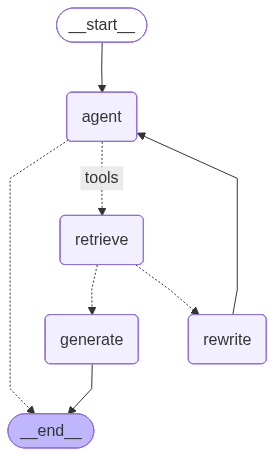

In [21]:
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Define a new graph
workflow = StateGraph(AgentState)

# Define the nodes we will cycle between
workflow.add_node("agent", agent)  # agent
retrieve = ToolNode([retriever_tool,retriever_tool_langchain])
workflow.add_node("retrieve", retrieve)  # retrieval
workflow.add_node("rewrite", rewrite)  # Re-writing the question
workflow.add_node(
    "generate", generate
)  # Generating a response after we know the documents are relevant
# Call agent node to decide to retrieve or not
workflow.add_edge(START, "agent")

# Decide whether to retrieve
workflow.add_conditional_edges(
    "agent",
    # Assess agent decision
    tools_condition,
    {
        # Translate the condition outputs to nodes in our graph
        "tools": "retrieve",
        END: END,
    },
)

# Edges taken after the `action` node is called.
workflow.add_conditional_edges(
    "retrieve",
    # Assess agent decision
    grade_documents,
)
workflow.add_edge("generate", END)
workflow.add_edge("rewrite", "agent")

# Compile
graph = workflow.compile()
from IPython.display import Image, display
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))


In [22]:
graph.invoke({"messages":"What is Langgraph?"})

---CALL AGENT---
---CHECK RELEVANCE---
---DECISION: DOCS RELEVANT---
---GENERATE---


NameError: name 'hub' is not defined

In [29]:
graph.invoke({"messages":"What is Langchain?"})

---CALL AGENT---
---CHECK RELEVANCE---


BadRequestError: Error code: 400 - {'error': {'message': 'Tool choice is required, but model did not call a tool', 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': 'yes'}}

In [30]:
graph.invoke({"messages":"What is Machine learning?"})

---CALL AGENT---


{'messages': [HumanMessage(content='What is Machine learning?', additional_kwargs={}, response_metadata={}, id='da579e9c-66b0-4b19-a061-60eea92740f1'),
  AIMessage(content='**Machine Learning (ML)** is a subset of artificial intelligence that enables computers to learn patterns and make predictions or decisions without being explicitly programmed for each specific task. Instead of writing detailed rules, you provide data and let the algorithm discover the underlying relationships.\n\n### Core Ideas\n| Concept | What it means |\n|---------|---------------|\n| **Training data** | A set of examples that the algorithm uses to learn. |\n| **Model** | The mathematical representation (e.g., a neural network, decision tree) that captures the learned patterns. |\n| **Learning algorithm** | The procedure (e.g., gradient descent) that adjusts the model’s parameters to fit the data. |\n| **Loss function** | A measure of how far the model’s predictions are from the true values; the algorithm tries 

### Fix Bugs

In [17]:
from typing import Annotated, Sequence, Literal, List
from typing_extensions import TypedDict

from pydantic import BaseModel, Field
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langchain_core.prompts import PromptTemplate

from langgraph.graph.message import add_messages
from langchain_groq import ChatGroq


# -----------------------------
# Tools
# -----------------------------
tools = [retriever_tool, retriever_tool_langchain]  # keep yours

# -----------------------------
# State (FIXED)
# -----------------------------
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]
    docs: List  # will store List[Document] (or list-like)
    question: str


# -----------------------------
# Agent node
# -----------------------------
def agent(state: AgentState):
    print("---CALL AGENT---")
    model = ChatGroq(model="openai/gpt-oss-20b").bind_tools(tools)
    response = model.invoke(list(state["messages"]))
    return {"messages": [response]}


# -----------------------------
# Retrieve node (IMPORTANT)
# You must call your retriever tool here OR use ToolNode in graph.
# If you already use ToolNode, then update docs from the tool result.
# Below is a simple pattern if YOU have a retriever object directly.
# -----------------------------
def retrieve(state: AgentState):
    print("---RETRIEVE---")
    q = state["messages"][0].content  # first user question
    # If you have a retriever object:
    docs = retriever.get_relevant_documents(q)   # <- replace if needed
    return {"docs": docs, "question": q}


# -----------------------------
# Grade edge (FIXED to use state["docs"])
# -----------------------------
def grade_documents(state: AgentState) -> Literal["generate", "rewrite"]:
    print("---CHECK RELEVANCE---")

    class Grade(BaseModel):
        binary_score: str = Field(description="Relevance score 'yes' or 'no'")

    model = ChatGroq(model="openai/gpt-oss-20b")
    llm_with_tool = model.with_structured_output(Grade)

    prompt = PromptTemplate(
        template=(
            "You are a grader assessing relevance of retrieved context to a user question.\n"
            "Context:\n{context}\n\n"
            "Question: {question}\n\n"
            "If the context is relevant, answer 'yes' else 'no'."
        ),
        input_variables=["context", "question"],
    )

    # Format docs safely
    docs = state.get("docs", [])
    context = "\n\n".join(getattr(d, "page_content", str(d)) for d in docs)
    question = state.get("question") or state["messages"][0].content

    scored = (prompt | llm_with_tool).invoke({"context": context, "question": question})
    score = scored.binary_score.strip().lower()

    if score == "yes":
        print("---DECISION: DOCS RELEVANT---")
        return "generate"
    else:
        print("---DECISION: DOCS NOT RELEVANT---")
        return "rewrite"


# -----------------------------
# Generate node (NO hub + returns AIMessage)
# -----------------------------
def generate(state: AgentState):
    print("---GENERATE---")
    docs = state.get("docs", [])
    question = state.get("question") or state["messages"][0].content

    context = "\n\n".join(getattr(d, "page_content", str(d)) for d in docs)

    rag_prompt = PromptTemplate(
        template=(
            "You are a helpful assistant.\n"
            "Use ONLY the context to answer. If not enough info, say so.\n\n"
            "Context:\n{context}\n\n"
            "Question:\n{question}\n\n"
            "Answer (structured):\n"
            "1) Steps / what to do\n"
            "2) Records/evidence\n"
            "3) Notes\n"
        ),
        input_variables=["context", "question"],
    )

    llm = ChatGroq(model="openai/gpt-oss-20b")
    text = llm.invoke(rag_prompt.format(context=context, question=question)).content
    return {"messages": [AIMessage(content=text)]}


# -----------------------------
# Rewrite node (returns HumanMessage to replace question)
# -----------------------------
def rewrite(state: AgentState):
    print("---TRANSFORM QUERY---")
    question = state.get("question") or state["messages"][0].content

    prompt = (
        "Rewrite this question into a better retrieval query for ISO/QMS procedures.\n"
        "Keep it short, add ISO keywords if helpful, no invented facts.\n\n"
        f"Original: {question}\n"
        "Rewritten:"
    )

    model = ChatGroq(model="openai/gpt-oss-20b")
    rewritten = model.invoke([HumanMessage(content=prompt)]).content.strip()

    # Put rewritten question as the NEW first user message (simple approach)
    return {"messages": [HumanMessage(content=rewritten)], "question": rewritten}

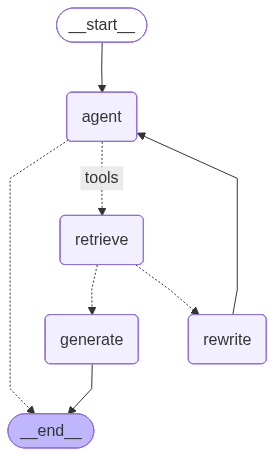

In [18]:
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Define a new graph
workflow = StateGraph(AgentState)

# Define the nodes we will cycle between
workflow.add_node("agent", agent)  # agent
retrieve = ToolNode([retriever_tool,retriever_tool_langchain])
workflow.add_node("retrieve", retrieve)  # retrieval
workflow.add_node("rewrite", rewrite)  # Re-writing the question
workflow.add_node(
    "generate", generate
)  # Generating a response after we know the documents are relevant
# Call agent node to decide to retrieve or not
workflow.add_edge(START, "agent")

# Decide whether to retrieve
workflow.add_conditional_edges(
    "agent",
    # Assess agent decision
    tools_condition,
    {
        # Translate the condition outputs to nodes in our graph
        "tools": "retrieve",
        END: END,
    },
)

# Edges taken after the `action` node is called.
workflow.add_conditional_edges(
    "retrieve",
    # Assess agent decision
    grade_documents,
)
workflow.add_edge("generate", END)
workflow.add_edge("rewrite", "agent")

# Compile
graph = workflow.compile()
from IPython.display import Image, display
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))


In [19]:
graph.invoke({"messages":"What is Langgraph?"})

---CALL AGENT---
---CHECK RELEVANCE---
---DECISION: DOCS NOT RELEVANT---
---TRANSFORM QUERY---
---CALL AGENT---


{'messages': [HumanMessage(content='What is Langgraph?', additional_kwargs={}, response_metadata={}, id='0edcd126-596c-4d20-9939-a230d8c2a3b5'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'User asks: "What is Langgraph?" Provide explanation. We can use function to retrieve info. Use retriever_vector_db_blog.', 'tool_calls': [{'id': 'fc_ae842cf4-4a8e-45f5-9cb5-ca8b18541885', 'function': {'arguments': '{"query":"Langgraph"}', 'name': 'retriever_vector_db_blog'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 56, 'prompt_tokens': 156, 'total_tokens': 212, 'completion_time': 0.056197779, 'completion_tokens_details': {'reasoning_tokens': 28}, 'prompt_time': 0.007463121, 'prompt_tokens_details': None, 'queue_time': 0.016302001, 'total_time': 0.0636609}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_8d13edce1d', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_ru

In [21]:
graph.invoke({"messages":"What is Langchain?"})

---CALL AGENT---


{'messages': [HumanMessage(content='What is Langchain?', additional_kwargs={}, response_metadata={}, id='6db15e52-9ce0-4429-88fa-d3ae08d1f1c1'),
  AIMessage(content='**LangChain** is an open‑source framework that helps developers build applications powered by large language models (LLMs). It abstracts away much of the boilerplate needed to connect an LLM to real‑world data, tools, and user interfaces, making it easier to create sophisticated, AI‑driven solutions.\n\n### Core ideas\n\n| Feature | What it means |\n|---------|---------------|\n| **Chainable components** | Think of each step in an AI workflow (e.g., prompt generation, LLM call, post‑processing) as a *node* that can be linked to others. Chains let you string these nodes together in any order. |\n| **Prompt templates & dynamic prompts** | Reuse a base prompt while filling in variables at runtime, ensuring consistency and reducing duplication. |\n| **Memory** | Keep track of conversation state, user preferences, or past actio

In [22]:
graph.invoke({"messages":"What is Machine learning?"})

---CALL AGENT---


{'messages': [HumanMessage(content='What is Machine learning?', additional_kwargs={}, response_metadata={}, id='01eb8816-d82c-47eb-9b83-b864643ed029'),
  AIMessage(content='**Machine learning (ML)** is a branch of artificial intelligence that focuses on building systems that can learn from data, identify patterns, and make decisions with minimal human intervention.\n\n### Core Idea\nInstead of programming explicit rules for every possible situation, an ML model learns the underlying relationships in data through training. Once trained, it can generalize to new, unseen data.\n\n### Main Categories\n\n| Type | What it does | Typical use‑cases |\n|------|--------------|-------------------|\n| **Supervised learning** | Learns a mapping from inputs to outputs using labeled examples. | Image classification, spam detection, house‑price prediction. |\n| **Unsupervised learning** | Discovers hidden structure in unlabeled data. | Clustering customers, anomaly detection, dimensionality reduction.